<a href="https://colab.research.google.com/github/EvenSol/NeqSim-Colab/blob/master/notebooks/fluidflow/neqsim_openfoam_cfd.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# NeqSim + OpenFOAM: natural-gas CFD with inline flow graphics

This notebook demonstrates a reproducible one-way coupling between NeqSim and
OpenFOAM. NeqSim calculates phase state and transport properties for a
methane-rich gas. Those properties define a turbulent OpenFOAM simulation of
flow over a backward-facing step. The OpenFOAM fields are then converted to
VTK and rendered directly in Colab as velocity, streamline, pressure, and
turbulence graphics.

**Learning outcomes**

- calculate density, viscosity, heat capacity, conductivity, and sound speed
  with an SRK fluid model in NeqSim;
- translate dynamic viscosity into the kinematic viscosity required by the
  incompressible OpenFOAM solver;
- derive Reynolds number and consistent $k$-$\epsilon$ inlet quantities;
- run and inspect an OpenFOAM 14 RANS case in a clean Colab runtime;
- convert kinematic pressure to Pa using the NeqSim density;
- validate flow conservation, pressure loss, and the expansion velocity;
- create publication-quality CFD contours and streamlines without a ParaView
  desktop.

## Coupling architecture

| Stage | Tool | Transferred quantity |
|---|---|---|
| Fluid definition | NeqSim 3.16.0 | Composition, phase, density, viscosity, sound speed |
| Interface | Python | $\nu=\mu/\rho$, Reynolds number, $k$, and $\epsilon$ |
| Flow solution | OpenFOAM 14 | RANS velocity, kinematic pressure, $k$, $\epsilon$, and $\nu_t$ fields |
| Interpretation | PyVista + Matplotlib | VTK sampling, pressure in Pa, contours, streamlines, and checks |

The coupling is deliberately transparent: every transferred quantity is
printed and checked. The OpenFOAM case remains available in `case_dir` for
additional post-processing.

## 1. Install the clean-runtime dependencies

OpenFOAM is installed without the ParaView desktop because PyVista reads the
generated VTK files directly. Installation is skipped when the requested
OpenFOAM environment is already available. A Colab runtime reset removes the
installation and the generated case.

In [1]:
import importlib.util
import os
from pathlib import Path
import shlex
import subprocess
import sys


NEQSIM_VERSION_REQUIRED = "3.16.0"
PYVISTA_VERSION_REQUIRED = "0.48.4"

python_requirements = {
    "neqsim": f"neqsim=={NEQSIM_VERSION_REQUIRED}",
    "pyvista": f"pyvista=={PYVISTA_VERSION_REQUIRED}",
}
missing_requirements = [
    package
    for module, package in python_requirements.items()
    if importlib.util.find_spec(module) is None
]

if missing_requirements:
    subprocess.check_call(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "--quiet",
            *missing_requirements,
        ]
    )

openfoam_override = os.environ.get("OPENFOAM_BASHRC_OVERRIDE")
default_openfoam_bashrc = Path("/opt/openfoam14/etc/bashrc")

if openfoam_override and Path(openfoam_override).is_file():
    OPENFOAM_BASHRC = Path(openfoam_override)
elif default_openfoam_bashrc.is_file():
    OPENFOAM_BASHRC = default_openfoam_bashrc
else:
    install_openfoam = r"""
set -euo pipefail
apt-get update -qq
DEBIAN_FRONTEND=noninteractive apt-get install -y -qq \
    ca-certificates software-properties-common wget
wget -qO- https://dl.openfoam.org/gpg.key \
    > /etc/apt/trusted.gpg.d/openfoam.asc
rm -f /etc/apt/sources.list.d/*dl_openfoam_org*list
add-apt-repository -y "http://dl.openfoam.org/ubuntu main dev"
apt-get update -qq
DEBIAN_FRONTEND=noninteractive apt-get install -y -qq \
    --no-install-recommends openfoam14
"""
    subprocess.run(
        ["bash", "-lc", install_openfoam],
        check=True,
    )
    OPENFOAM_BASHRC = default_openfoam_bashrc

openfoam_test = (
    f"source {shlex.quote(str(OPENFOAM_BASHRC))} >/dev/null 2>&1 "
    "&& foamRun -help >/dev/null"
)
subprocess.run(
    ["bash", "-lc", openfoam_test],
    check=True,
)

print("OpenFOAM 14 environment detected.")
print(f"Requested NeqSim version: {NEQSIM_VERSION_REQUIRED}")

OpenFOAM 14 environment detected.
Requested NeqSim version: 3.16.0


In [2]:
from importlib.metadata import version
import re
import shutil

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyvista as pv

from neqsim import jneqsim


NEQSIM_VERSION = version("neqsim")
PYVISTA_VERSION = version("pyvista")

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.float_format", lambda value: f"{value:,.6g}")

print(f"NeqSim version: {NEQSIM_VERSION}")
print(f"PyVista version: {PYVISTA_VERSION}")

NeqSim version: 3.16.0
PyVista version: 0.48.4


## 2. Define and flash the gas in NeqSim

The example uses mole fractions, SRK with the classic mixing rule, 25 °C, and
20 bara absolute. The composition is fictitious and non-proprietary. At this
state the mixture must remain a single gas phase.

In [3]:
TEMPERATURE_K = 298.15
PRESSURE_BARA = 20.0

gas_composition = {
    "nitrogen": 0.01,
    "CO2": 0.02,
    "methane": 0.88,
    "ethane": 0.06,
    "propane": 0.02,
    "n-butane": 0.01,
}

assert np.isclose(sum(gas_composition.values()), 1.0, atol=1.0e-12)

gas = jneqsim.thermo.system.SystemSrkEos(
    TEMPERATURE_K,
    PRESSURE_BARA,
)

for component_name, mole_fraction in gas_composition.items():
    gas.addComponent(component_name, mole_fraction)

gas.setMixingRule("classic")

operations = jneqsim.thermodynamicoperations.ThermodynamicOperations(gas)
operations.TPflash()
gas.initProperties()
gas.initPhysicalProperties()

gas_phase = gas.getPhase(0)
phase_label = str(gas_phase.getPhaseTypeName())
density_kg_per_m3 = gas_phase.getDensity("kg/m3")
dynamic_viscosity_pa_s = gas_phase.getViscosity("kg/msec")
kinematic_viscosity_m2_per_s = (
    dynamic_viscosity_pa_s / density_kg_per_m3
)
sound_speed_m_per_s = gas_phase.getSoundSpeed()

assert gas.getNumberOfPhases() == 1
assert phase_label == "gas"
assert density_kg_per_m3 > 0.0
assert dynamic_viscosity_pa_s > 0.0

fluid_properties = pd.Series(
    {
        "temperature [K]": gas.getTemperature("K"),
        "pressure [bara abs]": gas.getPressure("bara"),
        "phase": phase_label,
        "molar mass [kg/mol]": gas_phase.getMolarMass(),
        "compressibility factor Z [-]": gas_phase.getZ(),
        "density [kg/m3]": density_kg_per_m3,
        "dynamic viscosity [Pa s]": dynamic_viscosity_pa_s,
        "kinematic viscosity [m2/s]": kinematic_viscosity_m2_per_s,
        "Cp [J/(kg K)]": gas_phase.getCp("J/kgK"),
        "thermal conductivity [W/(m K)]": (
            gas_phase.getThermalConductivity("W/mK")
        ),
        "sound speed [m/s]": sound_speed_m_per_s,
    },
    name="NeqSim SRK gas",
)
fluid_properties

temperature [K]                       298.15
pressure [bara abs]                       20
phase                                    gas
molar mass [kg/mol]                0.0185455
compressibility factor Z [-]        0.955996
density [kg/m3]                      15.6646
dynamic viscosity [Pa s]         1.16088e-05
kinematic viscosity [m2/s]       7.41086e-07
Cp [J/(kg K)]                       2,197.23
thermal conductivity [W/(m K)]     0.0345725
sound speed [m/s]                    406.231
Name: NeqSim SRK gas, dtype: object

## 3. Translate the fluid state into CFD boundary data

OpenFOAM's incompressible solver uses kinematic pressure $p/\rho$ and
kinematic viscosity:

$$
\nu = \frac{\mu}{\rho}
$$

For a wide two-dimensional channel, the hydraulic diameter is approximated
as twice the inlet height. Reynolds number and the standard turbulence inlet
estimates are

$$
\mathrm{Re}=\frac{U D_h}{\nu}, \qquad
k=\frac{3}{2}(U I)^2, \qquad
\epsilon=C_\mu^{3/4}\frac{k^{3/2}}{L_t}.
$$

Here $I=5\%$, $C_\mu=0.09$, and $L_t=0.07D_h$. The 1 mm mesh thickness is
only a numerical slice; the front and back patches use the OpenFOAM `empty`
condition.

In [4]:
INLET_VELOCITY_M_PER_S = 10.0
INLET_HEIGHT_M = 0.0254
OUTLET_HEIGHT_M = 0.0332
NUMERICAL_SLICE_DEPTH_M = 0.001
HYDRAULIC_DIAMETER_M = 2.0 * INLET_HEIGHT_M
TURBULENCE_INTENSITY = 0.05
TURBULENCE_LENGTH_SCALE_M = 0.07 * HYDRAULIC_DIAMETER_M
C_MU = 0.09

reynolds_number = (
    INLET_VELOCITY_M_PER_S
    * HYDRAULIC_DIAMETER_M
    / kinematic_viscosity_m2_per_s
)
turbulent_kinetic_energy_m2_per_s2 = 1.5 * (
    INLET_VELOCITY_M_PER_S * TURBULENCE_INTENSITY
) ** 2
turbulent_dissipation_m2_per_s3 = (
    C_MU ** 0.75
    * turbulent_kinetic_energy_m2_per_s2 ** 1.5
    / TURBULENCE_LENGTH_SCALE_M
)
inlet_slice_area_m2 = INLET_HEIGHT_M * NUMERICAL_SLICE_DEPTH_M
inlet_slice_mass_flow_kg_per_s = (
    density_kg_per_m3
    * INLET_VELOCITY_M_PER_S
    * inlet_slice_area_m2
)
continuity_outlet_velocity_m_per_s = (
    INLET_VELOCITY_M_PER_S
    * INLET_HEIGHT_M
    / OUTLET_HEIGHT_M
)

assert reynolds_number > 4_000.0

coupling_table = pd.Series(
    {
        "inlet velocity [m/s]": INLET_VELOCITY_M_PER_S,
        "hydraulic diameter [m]": HYDRAULIC_DIAMETER_M,
        "Reynolds number [-]": reynolds_number,
        "turbulence intensity [%]": 100.0 * TURBULENCE_INTENSITY,
        "turbulent kinetic energy k [m2/s2]": (
            turbulent_kinetic_energy_m2_per_s2
        ),
        "dissipation epsilon [m2/s3]": (
            turbulent_dissipation_m2_per_s3
        ),
        "1 mm slice mass flow [kg/s]": inlet_slice_mass_flow_kg_per_s,
        "continuity outlet velocity [m/s]": (
            continuity_outlet_velocity_m_per_s
        ),
    },
    name="NeqSim-to-OpenFOAM interface",
)
coupling_table

inlet velocity [m/s]                        10
hydraulic diameter [m]                  0.0508
Reynolds number [-]                    685,480
turbulence intensity [%]                     5
turbulent kinetic energy k [m2/s2]       0.375
dissipation epsilon [m2/s3]            10.6113
1 mm slice mass flow [kg/s]          0.0039788
continuity outlet velocity [m/s]        7.6506
Name: NeqSim-to-OpenFOAM interface, dtype: float64

## 4. Build the OpenFOAM case

The geometry and numerical settings come from the OpenFOAM 14
`pitzDailySteady` tutorial. It contains a sudden expansion, a recirculation
region, and downstream recovery, making the transferred viscosity and the CFD
graphics more instructive than fully developed straight-pipe flow.

The notebook copies the tutorial into a writable directory and replaces only
the fluid viscosity, inlet velocity, $k$, and $\epsilon$ values.

In [5]:
def run_foam(command, timeout_seconds=600):
    library_path_override = os.environ.get(
        "OPENFOAM_LIBRARY_PATH_OVERRIDE",
        "",
    )
    library_export = ""

    if library_path_override:
        library_export = (
            "export LD_LIBRARY_PATH="
            f"{shlex.quote(library_path_override)}:$LD_LIBRARY_PATH && "
        )

    bash_command = (
        f"source {shlex.quote(str(OPENFOAM_BASHRC))} >/dev/null 2>&1 "
        f"&& {library_export}{command}"
    )
    completed = subprocess.run(
        ["bash", "-lc", bash_command],
        capture_output=True,
        text=True,
        timeout=timeout_seconds,
    )

    if completed.returncode != 0:
        print(completed.stdout)
        print(completed.stderr)
        raise RuntimeError(f"OpenFOAM command failed: {command}")

    return completed


def replace_pattern(path, pattern, replacement, flags=0):
    original = path.read_text()
    updated, replacement_count = re.subn(
        pattern,
        replacement,
        original,
        flags=flags,
    )

    if replacement_count == 0:
        raise RuntimeError(f"Pattern not found in {path}: {pattern}")

    path.write_text(updated)
    return replacement_count


tutorials_dir = Path(
    run_foam('printf "%s" "$FOAM_TUTORIALS"').stdout.strip()
)
tutorial_case = (
    tutorials_dir / "incompressibleFluid" / "pitzDailySteady"
)
runtime_root = Path("/content") if Path("/content").is_dir() else Path.cwd()
case_dir = runtime_root / "neqsim_openfoam_cfd_case"

if case_dir.is_dir():
    shutil.rmtree(case_dir)

shutil.copytree(tutorial_case, case_dir)

physical_properties_path = case_dir / "constant" / "physicalProperties"
velocity_path = case_dir / "0" / "U"
k_path = case_dir / "0" / "k"
epsilon_path = case_dir / "0" / "epsilon"

replace_pattern(
    physical_properties_path,
    r"(?m)^nu\s+[^;]+;",
    f"nu              {kinematic_viscosity_m2_per_s:.9g};",
)
replace_pattern(
    velocity_path,
    r"(inlet\s*\{.*?value\s+uniform\s*)\([^)]*\)(;)",
    (
        r"\g<1>"
        f"({INLET_VELOCITY_M_PER_S:.9g} 0 0)"
        r"\g<2>"
    ),
    flags=re.DOTALL,
)
replace_pattern(
    k_path,
    r"uniform\s+0\.375;",
    f"uniform {turbulent_kinetic_energy_m2_per_s2:.9g};",
)
replace_pattern(
    epsilon_path,
    r"uniform\s+14\.855;",
    f"uniform {turbulent_dissipation_m2_per_s3:.9g};",
)

print(f"Runtime case: {case_dir.name}")
print(
    physical_properties_path.read_text().split("nu", maxsplit=1)[-1]
    .splitlines()[0]
    .strip()
)

Runtime case: neqsim_openfoam_cfd_case
7.41086035e-07;


## 5. Mesh and solve

The case uses steady RANS, the standard $k$-$\epsilon$ model, no-slip walls,
a fixed inlet velocity, and fixed outlet kinematic pressure. OpenFOAM stops
when the tutorial's residual criteria are met. Typical solve time is well
under one minute after installation on a Colab CPU runtime.

In [6]:
mesh_result = run_foam(
    f"blockMesh -case {shlex.quote(str(case_dir))}",
)
(case_dir / "log.blockMesh").write_text(mesh_result.stdout)

solver_result = run_foam(
    f"foamRun -case {shlex.quote(str(case_dir))}",
)
(case_dir / "log.foamRun").write_text(solver_result.stdout)

assert "SIMPLE solution converged" in solver_result.stdout
assert "End" in solver_result.stdout

solver_tail = "\n".join(solver_result.stdout.splitlines()[-18:])
print(solver_tail)


smoothSolver:  Solving for Ux, Initial residual = 0.000106278, Final residual = 1.0169e-05, No Iterations 5
smoothSolver:  Solving for Uy, Initial residual = 0.000974669, Final residual = 9.71333e-05, No Iterations 5
GAMG:  Solving for p, Initial residual = 0.00365464, Final residual = 0.000179397, No Iterations 2
time step continuity errors : sum local = 0.0110134, global = 0.000350188, cumulative = 0.746143
smoothSolver:  Solving for epsilon, Initial residual = 0.000162945, Final residual = 1.55503e-05, No Iterations 2
smoothSolver:  Solving for k, Initial residual = 0.000159242, Final residual = 9.57912e-06, No Iterations 4
ExecutionTime = 5.56078 s  ClockTime = 5 s


SIMPLE solution converged in 317 iterations

streamlines streamlines write:
    Seeded 10 particles
Sampled 10900 locations

End



In [7]:
conversion_result = run_foam(
    (
        f"foamToVTK -case {shlex.quote(str(case_dir))} "
        "-latestTime"
    )
)
(case_dir / "log.foamToVTK").write_text(conversion_result.stdout)

latest_time = run_foam(
    (
        f"foamListTimes -case {shlex.quote(str(case_dir))} "
        "-latestTime"
    )
).stdout.strip()
vtk_path = case_dir / "VTK" / f"{case_dir.name}_{latest_time}.vtk"

mesh = pv.read(vtk_path)
velocity_vectors = mesh.point_data["U"]
mesh.point_data["velocity_magnitude"] = np.linalg.norm(
    velocity_vectors,
    axis=1,
)
mesh.point_data["relative_pressure_Pa"] = (
    density_kg_per_m3 * mesh.point_data["p"]
)

print(f"Converged OpenFOAM time index: {latest_time}")
print(f"Cells: {mesh.n_cells:,}")
print(f"Points: {mesh.n_points:,}")
print(f"VTK result: {vtk_path.name}")

Converged OpenFOAM time index: 317
Cells: 12,225
Points: 25,012
VTK result: neqsim_openfoam_cfd_case_317.vtk


## 6. Create inline CFD graphics

PyVista samples the actual OpenFOAM VTK solution onto a regular plane.
Matplotlib then renders a consistent three-panel engineering view. White
regions are outside the backward-facing-step flow domain.

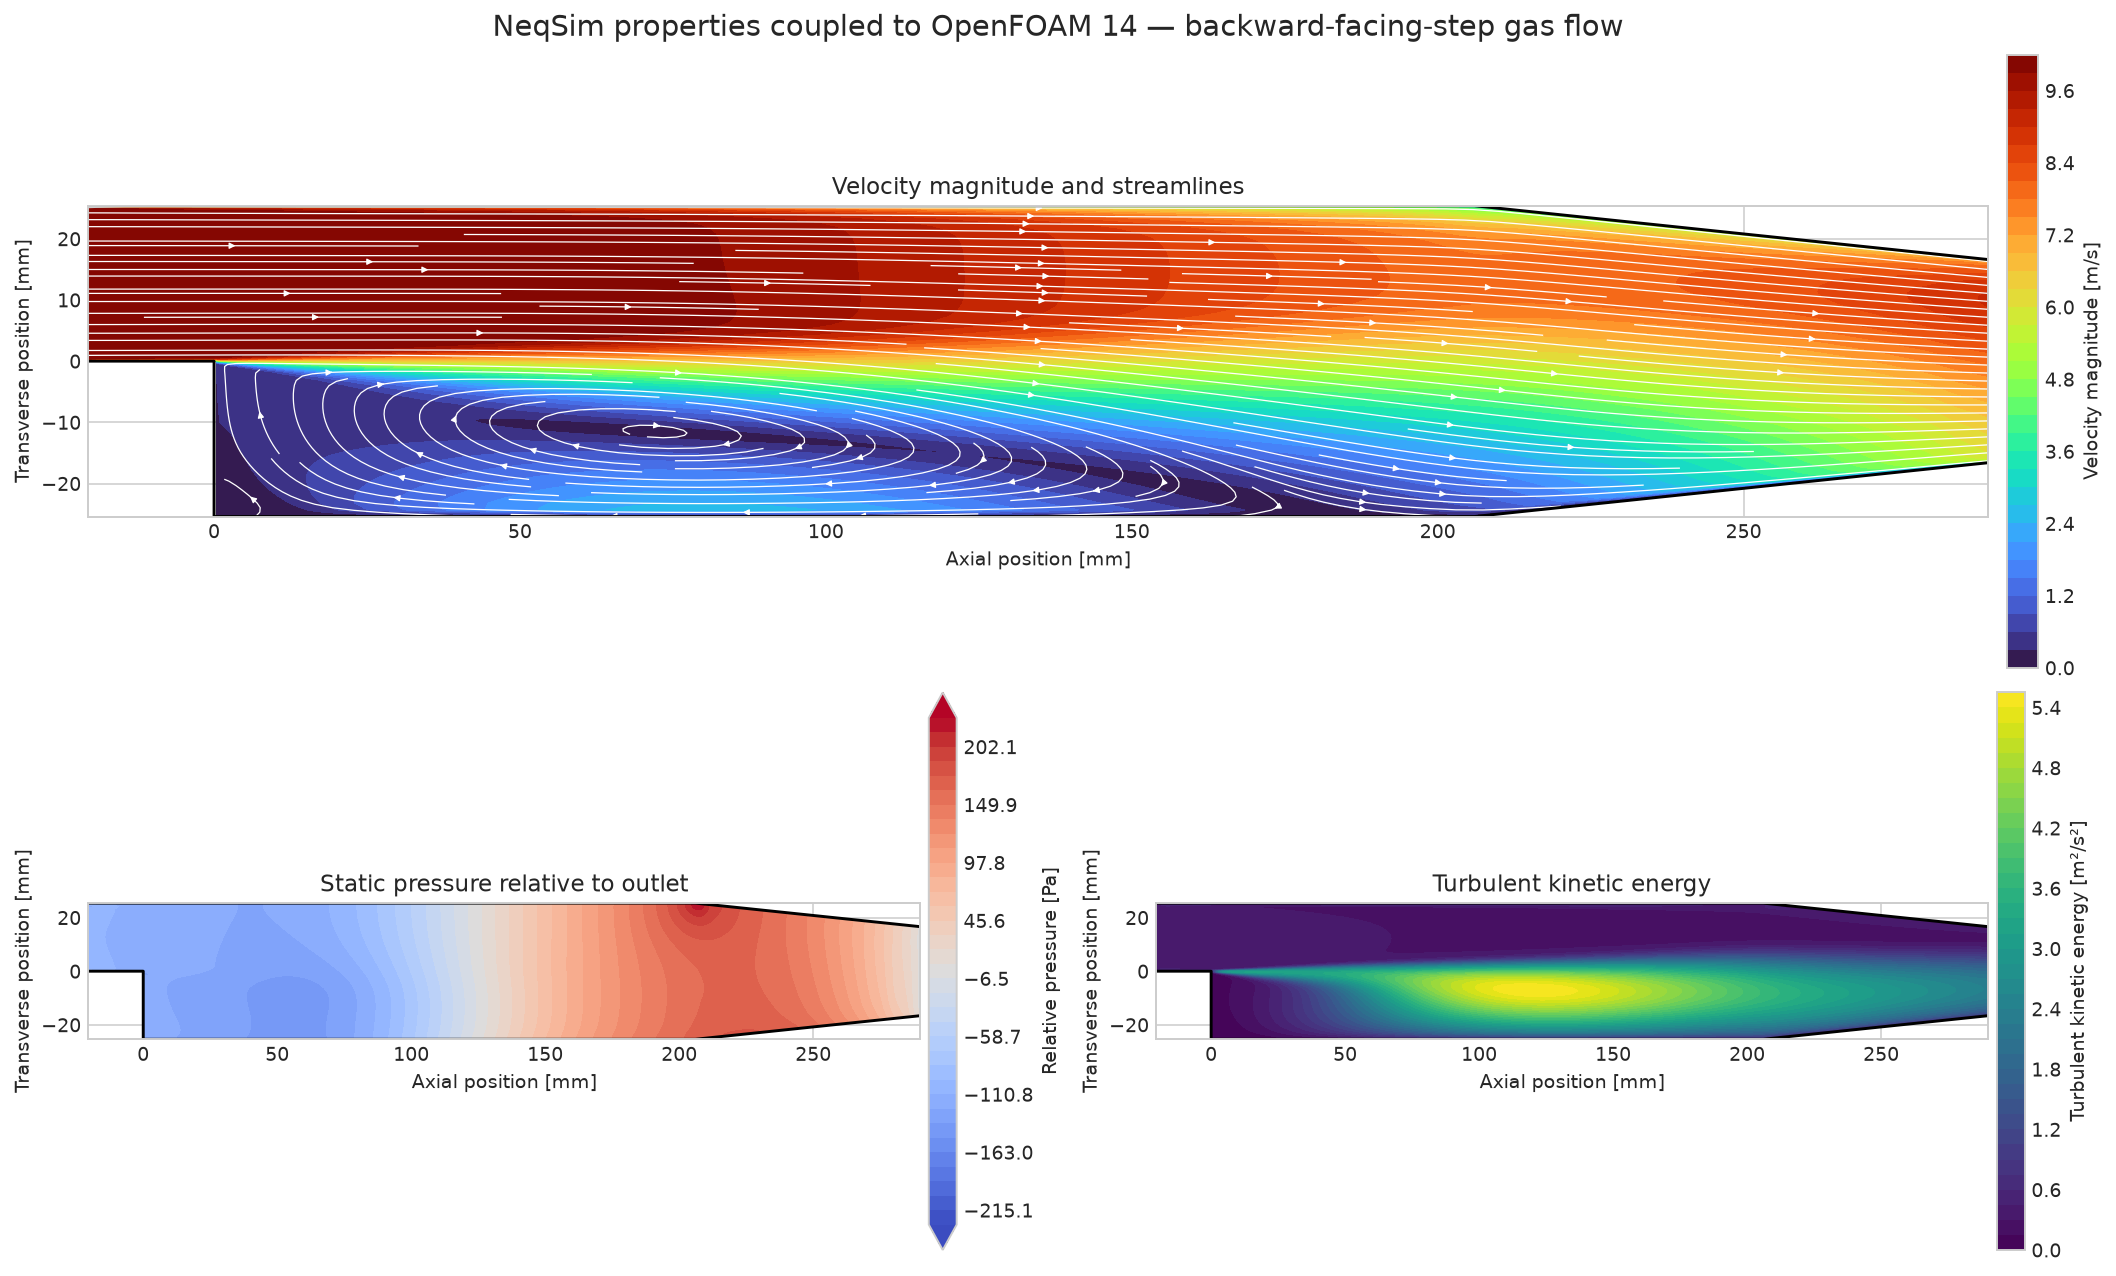

In [8]:
x_values_m = np.linspace(mesh.bounds.x_min, mesh.bounds.x_max, 520)
y_values_m = np.linspace(mesh.bounds.y_min, mesh.bounds.y_max, 190)
x_grid_m, y_grid_m = np.meshgrid(x_values_m, y_values_m)
sample_coordinates = np.column_stack(
    [
        x_grid_m.ravel(),
        y_grid_m.ravel(),
        np.zeros(x_grid_m.size),
    ]
)
sample_points = pv.PolyData(sample_coordinates)
sampled = sample_points.sample(mesh)

valid_mask = sampled.point_data["vtkValidPointMask"].reshape(
    x_grid_m.shape
).astype(bool)
sampled_velocity = sampled.point_data["U"].reshape(
    *x_grid_m.shape,
    3,
)
sampled_kinematic_pressure = sampled.point_data["p"].reshape(
    x_grid_m.shape
)
sampled_k = sampled.point_data["k"].reshape(x_grid_m.shape)

sampled_speed = np.linalg.norm(sampled_velocity, axis=2)
sampled_pressure_pa = density_kg_per_m3 * sampled_kinematic_pressure

speed_field = np.ma.masked_where(~valid_mask, sampled_speed)
pressure_field = np.ma.masked_where(~valid_mask, sampled_pressure_pa)
k_field = np.ma.masked_where(~valid_mask, sampled_k)
u_field = np.ma.masked_where(~valid_mask, sampled_velocity[:, :, 0])
v_field = np.ma.masked_where(~valid_mask, sampled_velocity[:, :, 1])

x_values_mm = 1_000.0 * x_values_m
y_values_mm = 1_000.0 * y_values_m


def draw_channel_walls(axis):
    upper_x_mm = np.array([-20.6, 206.0, 290.0])
    upper_y_mm = np.array([25.4, 25.4, 16.6])
    lower_x_mm = np.array([-20.6, 0.0, 0.0, 206.0, 290.0])
    lower_y_mm = np.array([0.0, 0.0, -25.4, -25.4, -16.6])
    axis.plot(upper_x_mm, upper_y_mm, color="black", linewidth=1.5)
    axis.plot(lower_x_mm, lower_y_mm, color="black", linewidth=1.5)
    axis.set_xlim(x_values_mm.min(), x_values_mm.max())
    axis.set_ylim(y_values_mm.min(), y_values_mm.max())
    axis.set_aspect("equal", adjustable="box")
    axis.set_xlabel("Axial position [mm]")
    axis.set_ylabel("Transverse position [mm]")


figure = plt.figure(figsize=(15, 9), constrained_layout=True)
grid_spec = figure.add_gridspec(2, 2, height_ratios=[1.1, 1.0])

speed_axis = figure.add_subplot(grid_spec[0, :])
speed_contours = speed_axis.contourf(
    x_values_mm,
    y_values_mm,
    speed_field,
    levels=36,
    cmap="turbo",
)
speed_axis.streamplot(
    x_values_mm,
    y_values_mm,
    u_field,
    v_field,
    color="white",
    density=(2.3, 1.35),
    linewidth=0.65,
    arrowsize=0.65,
)
draw_channel_walls(speed_axis)
speed_axis.set_title("Velocity magnitude and streamlines")
figure.colorbar(
    speed_contours,
    ax=speed_axis,
    label="Velocity magnitude [m/s]",
    pad=0.01,
)

pressure_axis = figure.add_subplot(grid_spec[1, 0])
pressure_limit = float(np.nanmax(np.abs(pressure_field)))
pressure_levels = np.linspace(-pressure_limit, pressure_limit, 36)
pressure_contours = pressure_axis.contourf(
    x_values_mm,
    y_values_mm,
    pressure_field,
    levels=pressure_levels,
    cmap="coolwarm",
    extend="both",
)
draw_channel_walls(pressure_axis)
pressure_axis.set_title("Static pressure relative to outlet")
figure.colorbar(
    pressure_contours,
    ax=pressure_axis,
    label="Relative pressure [Pa]",
    pad=0.01,
)

k_axis = figure.add_subplot(grid_spec[1, 1])
k_contours = k_axis.contourf(
    x_values_mm,
    y_values_mm,
    k_field,
    levels=36,
    cmap="viridis",
)
draw_channel_walls(k_axis)
k_axis.set_title("Turbulent kinetic energy")
figure.colorbar(
    k_contours,
    ax=k_axis,
    label="Turbulent kinetic energy [m²/s²]",
    pad=0.01,
)

figure.suptitle(
    "NeqSim properties coupled to OpenFOAM 14 — backward-facing-step gas flow",
    fontsize=15,
)
plt.show()

## 7. Engineering validation

The inlet and outlet VTK patches provide area-weighted flow quantities. The
checks compare the CFD outlet velocity with the area-ratio estimate, close
the mass flow, and distinguish static pressure recovery from irreversible
total-pressure loss.

In [9]:
def calculate_patch_metrics(patch_name):
    patch_path = (
        case_dir
        / "VTK"
        / patch_name
        / f"{patch_name}_{latest_time}.vtk"
    )
    patch = pv.read(patch_path).compute_cell_sizes(
        length=False,
        area=True,
        volume=False,
    )
    areas_m2 = patch.cell_data["Area"]
    velocity = patch.cell_data["U"]
    kinematic_pressure = patch.cell_data["p"]
    speed_squared = np.sum(velocity * velocity, axis=1)

    def area_average(values):
        return float(np.average(values, weights=areas_m2))

    volumetric_flow_m3_per_s = abs(
        float(np.sum(velocity[:, 0] * areas_m2))
    )

    return {
        "area [m2]": float(np.sum(areas_m2)),
        "area-average Ux [m/s]": area_average(velocity[:, 0]),
        "volumetric flow [m3/s]": volumetric_flow_m3_per_s,
        "mass flow [kg/s]": (
            density_kg_per_m3 * volumetric_flow_m3_per_s
        ),
        "static pressure [Pa rel.]": (
            density_kg_per_m3 * area_average(kinematic_pressure)
        ),
        "total pressure [Pa rel.]": (
            density_kg_per_m3
            * area_average(kinematic_pressure + 0.5 * speed_squared)
        ),
    }


inlet_metrics = calculate_patch_metrics("inlet")
outlet_metrics = calculate_patch_metrics("outlet")

mass_balance_error_percent = 100.0 * abs(
    outlet_metrics["mass flow [kg/s]"]
    - inlet_metrics["mass flow [kg/s]"]
) / inlet_metrics["mass flow [kg/s]"]
outlet_velocity_error_percent = 100.0 * abs(
    outlet_metrics["area-average Ux [m/s]"]
    - continuity_outlet_velocity_m_per_s
) / continuity_outlet_velocity_m_per_s
static_pressure_recovery_pa = (
    outlet_metrics["static pressure [Pa rel.]"]
    - inlet_metrics["static pressure [Pa rel.]"]
)
total_pressure_loss_pa = (
    inlet_metrics["total pressure [Pa rel.]"]
    - outlet_metrics["total pressure [Pa rel.]"]
)
minimum_axial_velocity_m_per_s = float(
    np.min(mesh.point_data["U"][:, 0])
)
maximum_velocity_m_per_s = float(
    np.max(mesh.point_data["velocity_magnitude"])
)
maximum_mach_number = maximum_velocity_m_per_s / sound_speed_m_per_s
maximum_relative_pressure_fraction = (
    float(np.max(np.abs(mesh.point_data["relative_pressure_Pa"])))
    / (PRESSURE_BARA * 1.0e5)
)

validation_table = pd.Series(
    {
        "CFD outlet velocity [m/s]": (
            outlet_metrics["area-average Ux [m/s]"]
        ),
        "area-ratio outlet velocity [m/s]": (
            continuity_outlet_velocity_m_per_s
        ),
        "outlet velocity deviation [%]": outlet_velocity_error_percent,
        "mass balance error [%]": mass_balance_error_percent,
        "static pressure recovery [Pa]": static_pressure_recovery_pa,
        "total pressure loss [Pa]": total_pressure_loss_pa,
        "minimum axial velocity [m/s]": minimum_axial_velocity_m_per_s,
        "maximum Mach number [-]": maximum_mach_number,
        "max |relative p| / absolute p [%]": (
            100.0 * maximum_relative_pressure_fraction
        ),
    },
    name="Validation",
)

assert mass_balance_error_percent < 2.0
assert outlet_velocity_error_percent < 3.0
assert static_pressure_recovery_pa > 0.0
assert total_pressure_loss_pa > 0.0
assert minimum_axial_velocity_m_per_s < 0.0
assert maximum_mach_number < 0.1
assert maximum_relative_pressure_fraction < 0.01

validation_table

CFD outlet velocity [m/s]             7.61986
area-ratio outlet velocity [m/s]       7.6506
outlet velocity deviation [%]         0.40185
mass balance error [%]               0.401851
static pressure recovery [Pa]         108.293
total pressure loss [Pa]              209.866
minimum axial velocity [m/s]         -2.56161
maximum Mach number [-]             0.0249144
max |relative p| / absolute p [%]   0.0114443
Name: Validation, dtype: float64

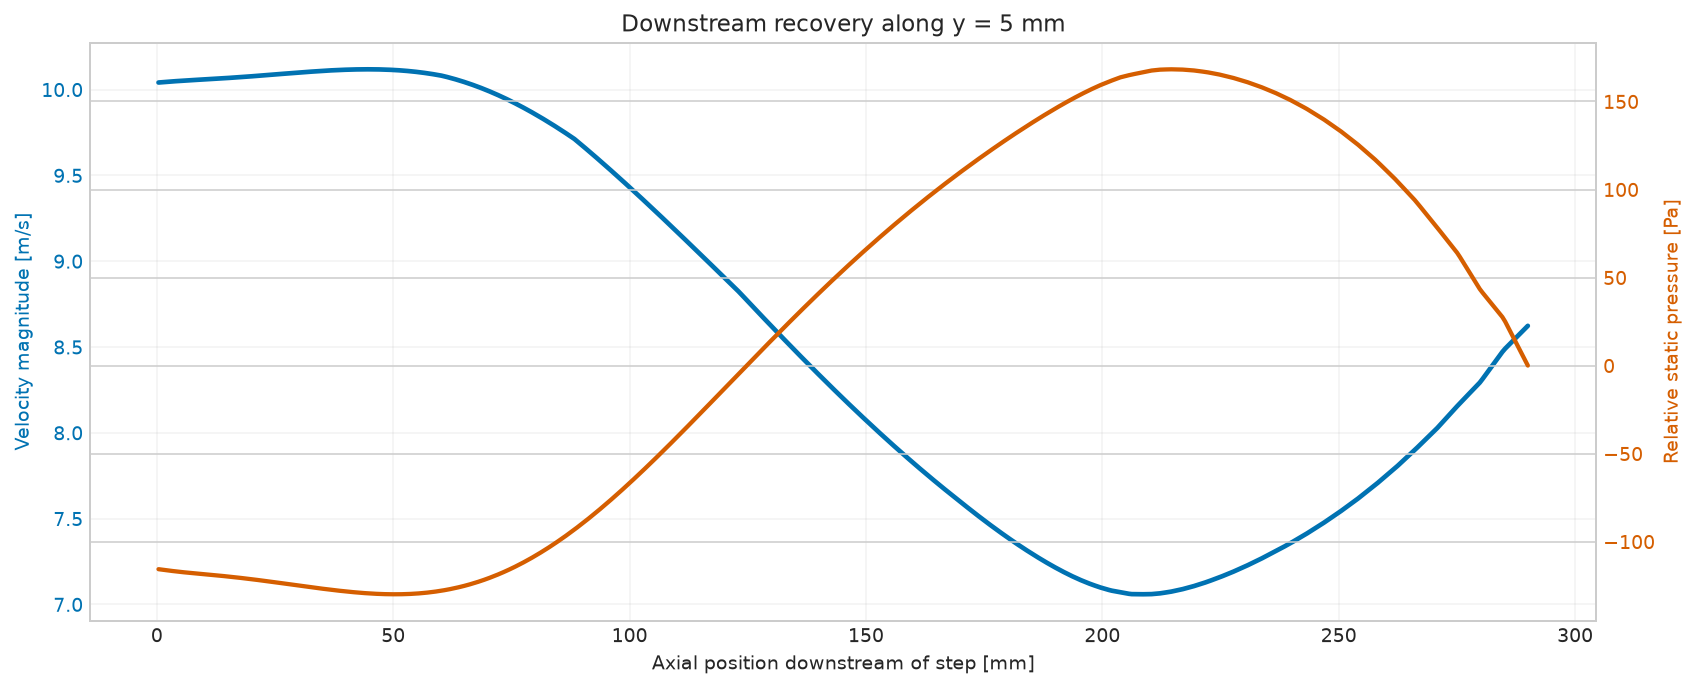

In [10]:
profile_y_m = 0.005
profile_row = int(np.argmin(np.abs(y_values_m - profile_y_m)))
profile_mask = valid_mask[profile_row] & (x_values_m >= 0.0)
profile_x_mm = x_values_mm[profile_mask]
profile_speed = sampled_speed[profile_row, profile_mask]
profile_pressure = sampled_pressure_pa[profile_row, profile_mask]

profile_figure, velocity_axis = plt.subplots(
    figsize=(12, 4.8),
    constrained_layout=True,
)
pressure_axis = velocity_axis.twinx()

velocity_axis.plot(
    profile_x_mm,
    profile_speed,
    color="#0072B2",
    linewidth=2.4,
    label="Velocity magnitude",
)
pressure_axis.plot(
    profile_x_mm,
    profile_pressure,
    color="#D55E00",
    linewidth=2.2,
    label="Static pressure",
)

velocity_axis.set_xlabel("Axial position downstream of step [mm]")
velocity_axis.set_ylabel("Velocity magnitude [m/s]", color="#0072B2")
pressure_axis.set_ylabel("Relative static pressure [Pa]", color="#D55E00")
velocity_axis.tick_params(axis="y", colors="#0072B2")
pressure_axis.tick_params(axis="y", colors="#D55E00")
velocity_axis.set_title(
    "Downstream recovery along y = 5 mm"
)
velocity_axis.grid(True, alpha=0.25)
plt.show()

## Interpretation

- The negative axial velocity immediately downstream of the step confirms a
  separated recirculation zone.
- The larger outlet area lowers the bulk velocity and produces static-pressure
  recovery, while the positive total-pressure loss captures irreversible
  mixing and wall friction.
- The CFD outlet velocity agrees with the independent area-ratio estimate and
  inlet/outlet mass flow closes within the asserted tolerance.
- The Mach number and pressure variation are small relative to the NeqSim
  absolute state, supporting the constant-density approximation for this
  educational case.

## Limitations and extensions

This is a one-way, isothermal coupling. NeqSim properties are evaluated once
at the reference state and remain constant in the CFD domain. The standard
$k$-$\epsilon$ model and tutorial mesh are appropriate for teaching and
workflow verification, not design certification. No mesh-independence,
near-wall $y^+$, turbulence-model, or experimental benchmark study is claimed.

For larger pressure or temperature changes, use a compressible and energy-
coupled OpenFOAM solver and update density, viscosity, heat capacity, and
conductivity as functions of local state. Multiphase evaporation, droplets,
or liquid films additionally require phase-resolved or Euler-Lagrange models
plus a defined mass- and heat-transfer coupling to NeqSim.

Suggested exercises:

1. Change pressure, temperature, or gas composition and quantify how NeqSim's
   viscosity changes Reynolds number and the recirculation field.
2. Repeat at 5 and 20 m/s and compare pressure loss with $U^2$ scaling.
3. Refine the mesh and compare standard $k$-$\epsilon$ with $k$-$\omega$ SST.
4. Replace the constant-property model with tabulated NeqSim properties for a
   non-isothermal compressible case.

## Reproducibility and references

**Validated stack:** NeqSim 3.16.0, OpenFOAM Foundation 14, Python 3.12, and
PyVista 0.48.4. The notebook records the solver convergence text, embeds the
actual CFD graphics, and performs executable conservation and physical checks.

- [NeqSim documentation](https://equinor.github.io/neqsim/)
- [OpenFOAM 14 Ubuntu installation](https://openfoam.org/download/14-ubuntu/)
- [OpenFOAM `pitzDailySteady` source case](https://github.com/OpenFOAM/OpenFOAM-dev/tree/master/tutorials/incompressibleFluid/pitzDailySteady)
- [PyVista documentation](https://docs.pyvista.org/)